In [1]:
import importlib
import md_Helpers

importlib.reload(md_Helpers)

from md_Helpers import open_run


run = open_run("20260918183312")
run.info()

Run_ID,Sim_Type,Status,Directory,Trajectory,HDF5,Frame_Count
20260918183312,Cavitation,Complete,/exp/e961/data/MDsims-data/pnichols/SQL/Cavitation/20260918183312,/exp/e961/data/MDsims-data/pnichols/SQL/Cavitation/20260918183312/trajectory.gsd,/exp/e961/data/MDsims-data/pnichols/SQL/Cavitation/20260918183312/run.hdf5,16


Run_ID,Run_Signature,N_Cells,Nsteps,Current_Nstep,ElapsedTime,StartTime,EndTime,Last_Update_Time,Sim_Type,Status,Stop_Reason,Status_Message,Notes
20260918183312,6fb634cf3a5f8c905c36338a85f569beb9d3f296de1f4280448c9ea91bd8a016,25,250000,250000,123.523327,2026-09-18 18:33:13.440540,2026-09-18 18:35:33.165457,2026-09-18 18:35:33.165457,Cavitation,Complete,None,None,Seeded a centered spherical cavity of radius 8 from final frame 5 of thermalization Run_ID 20260917210025; evolved in NVT for 250000 steps.


Run_ID,File_Location,Source_Run_ID,Source_Frame_ID,N_Cells,Therm_kT,Therm_Seed,Source_Density,Initial_Density,BoxLength,Mask_Radius,Random_Location,Location_Seed,dt,Nsteps,This_LJ_Time,Cumulative_LJ_Time,Ensemble,T_Set,P_Set,LJ_r_cut,LJ_r_on,LJ_Mode,Phase_Separation_Status,Phase_Separation_Method,Phase_Separation_Method_Version,rho_liquid,rho_liquid_unc,rho_gas,rho_gas_unc,V_liquid,V_liquid_unc,V_gas,V_gas_unc,Phase_Fit_Status,Phase_Fit_Method,Phase_Fit_Method_Version,Summary_Start_Step,Summary_End_Step,Summary_Num_Samples,Pressure_Mean,Pressure_Std,Pressure_SEM,PE_Per_Particle_Mean,PE_Per_Particle_Std,PE_Per_Particle_SEM,Num_Frames
20260918183312,Cavitation/20260918183312,20260917210025,5,25,1.000000,1,0.580000,0.568020,47.586525,8.000000,0,None,0.002000,250000,500.000000,900.000000,NVT,1.000000,None,2.500000,2.000000,xplor,Separated,voxel_histogram,voxel_low_density_fraction_v1,0.607235,0.000819,0.048670,0.008971,99811.851393,372.120921,7946.756937,372.120921,Complete,averaged_voxel_histogram_mixture,terminal_5_saved_frames_log_stride_10_v2,151000,250000,100,0.009267,0.012733,0.001273,-3.751707,0.008872,0.000887,16


{'Run_ID': '20260918183312',
 'Sim_Type': 'Cavitation',
 'Status': 'Complete',
 'Directory': '/exp/e961/data/MDsims-data/pnichols/SQL/Cavitation/20260918183312',
 'Trajectory': '/exp/e961/data/MDsims-data/pnichols/SQL/Cavitation/20260918183312/trajectory.gsd',
 'HDF5': '/exp/e961/data/MDsims-data/pnichols/SQL/Cavitation/20260918183312/run.hdf5',
 'Frame_Count': 16}

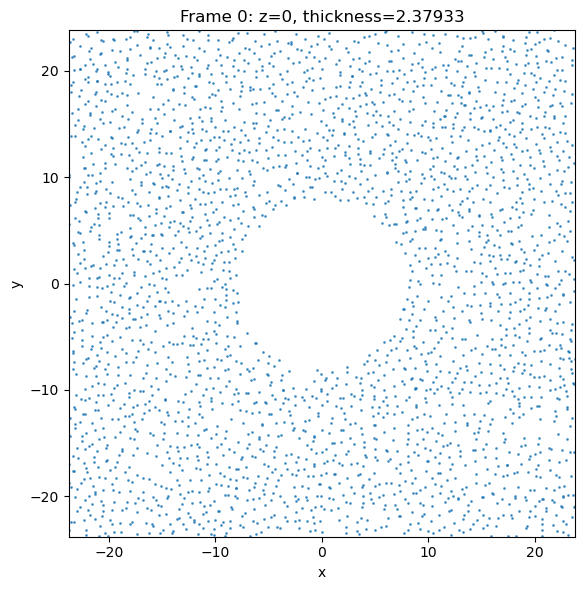

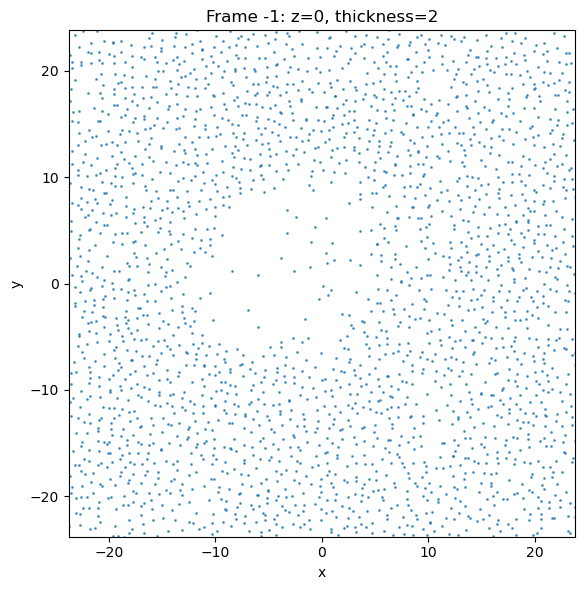

In [2]:
# 3D views
#run.render(frame=0)
#run.render(frame=-1)
#run.render_movie()

# XY slices
run.xy_slice(frame=0)
run.xy_slice(frame=-1, z=0, thickness=2.0);
#run.xy_slice(frames=[0, 10, 20, -1])
run.xy_slice_movie(frame_step=1);

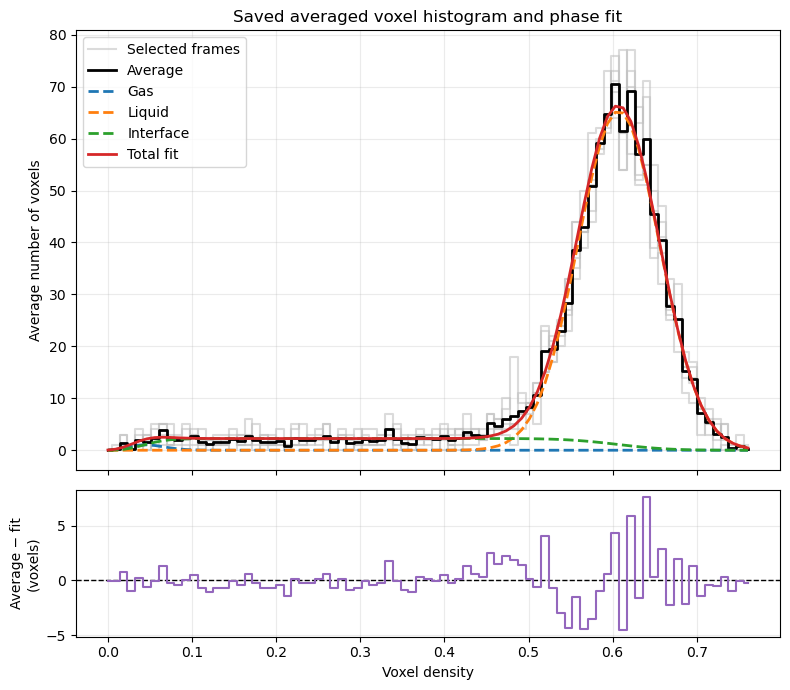

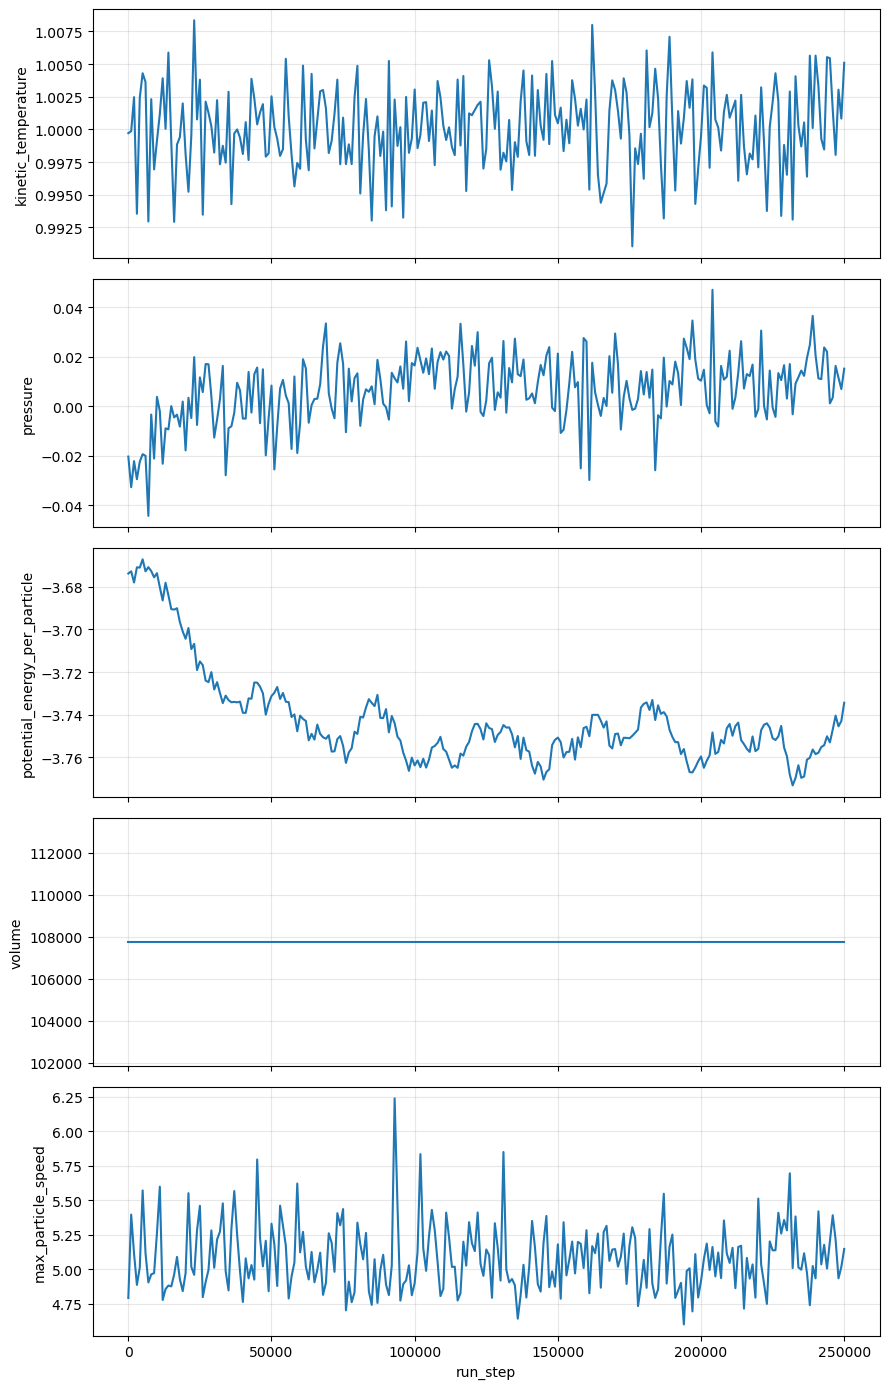

In [3]:
# Phase fit and logs
run.plot_phase_fit();
run.plot_logs();

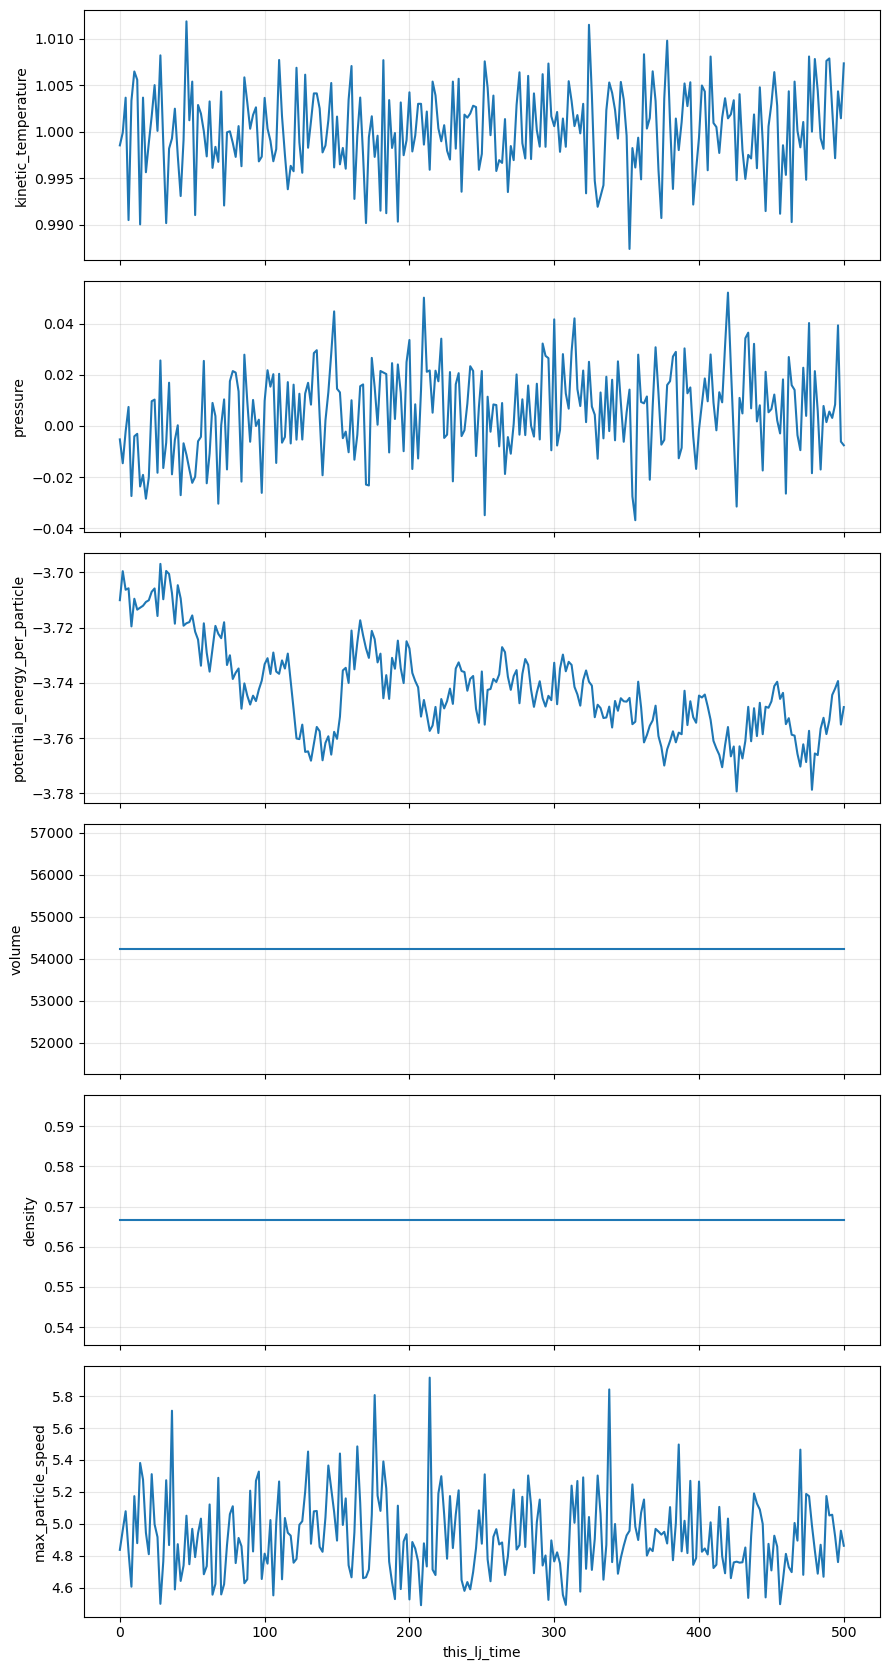

In [24]:
run.plot_logs(
    [
        "kinetic_temperature",
        "pressure",
        "potential_energy_per_particle",
        "volume",
        "density",
        "max_particle_speed",
    ],
    x="this_lj_time",
);

#x="frame"
#x="hoomd_timestep"
#x="run_step"
#x="this_lj_time"
#x="cumulative_lj_time"

In [12]:
logs = run.logs_dataframe()
metadata = run.metadata()
frame_table = run.frame_table()

for field, value in metadata.items():
    print(f"{field}: {value}")

mdsims/analysis/phase_fit/AIC: 138374.12876191625
mdsims/analysis/phase_fit/BIC: 138412.79670449495
mdsims/analysis/phase_fit/V_gas: 104963.0886374296
mdsims/analysis/phase_fit/V_gas_unc: 1419.4156144863016
mdsims/analysis/phase_fit/V_liquid: 407036.9113625704
mdsims/analysis/phase_fit/V_liquid_unc: 1419.4156144863011
mdsims/analysis/phase_fit/box_volume: 512000.0
mdsims/analysis/phase_fit/count_axis: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114]
mdsims/analysis/phase_fit/density_axis: [0.         0.0065918  0.01318359 0.01977539 0.02636719 0.03295898
 0.03955078 0.046142

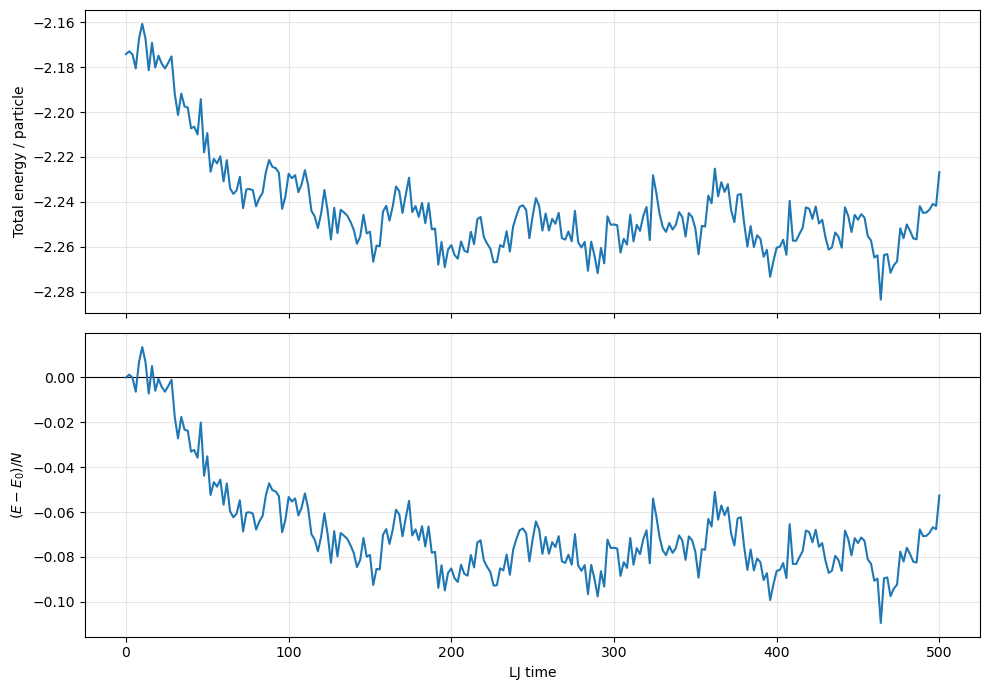

In [4]:
import matplotlib.pyplot as plt

logs = run.logs_dataframe()

logs["total_energy"] = (
    logs["kinetic_energy"]
    + logs["potential_energy"]
)

logs["total_energy_per_particle"] = (
    logs["total_energy"]
    / logs["num_particles"]
)

initial_energy = logs["total_energy_per_particle"].iloc[0]

logs["energy_change_per_particle"] = (
    logs["total_energy_per_particle"]
    - initial_energy
)

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

axes[0].plot(
    logs["this_lj_time"],
    logs["total_energy_per_particle"],
)

axes[0].set_ylabel("Total energy / particle")
axes[0].grid(alpha=0.3)

axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].plot(
    logs["this_lj_time"],
    logs["energy_change_per_particle"],
)

axes[1].set_xlabel("LJ time")
axes[1].set_ylabel(r"$(E-E_0)/N$")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()